# Results for Paper "Evaluating the Educational Impact of a Large Language Model (LLM)Based Virtual Assistant in Video-Based Learning"

---

In [80]:
import os, sys
import polars as pl

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

data_filename = 'processed_forms_interactions_data.parquet'
data_path = os.path.join(project_path, 'data', 'combined', data_filename)

sys.path.append(project_path)
from src.utils.educational_impact.educational_impact_analysis import (
    rename_df,
    group_stats,
    compute_correlations,
    plot_cat_distribution,
    plot_cat_comparison,
    plot_quant_distribution,
    plot_quant_comparison,
    plot_quant_comparison_faceted,
    plot_quant_scatter,
    plot_quant_pie,
    plot_cat_comparison_faceted,
    plot_cat_comparison_heatmap,
    plot_cat_comparison_faceted_heatmap
)

forms_interactions_df = pl.read_parquet(data_path)


#Rename df for figures
forms_interactions_df = rename_df(forms_interactions_df)


---

## Vista de la tabla

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [81]:
forms_interactions_df['group'].value_counts()

group,count
str,u32
"""experimental""",94
"""control""",97


In [82]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
"""High""",29
null,100
"""Not Used""",29
"""Low""",9
"""Medium""",24


In [83]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [84]:
forms_interactions_df['group'].value_counts().filter(pl.col('group') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Si --> No problema



In [85]:
forms_interactions_df.filter(
    pl.col('group') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,mejora_retention_hake_gain,mejora_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,score_tc_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,group_segmented_freq_quality,group_segmented_quality,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,bool,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64


Hay alguno de experimental con null en la herramienta? --> Si --> Problema

In [86]:
forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,mejora_retention_hake_gain,mejora_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,score_tc_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,group_segmented_freq_quality,group_segmented_quality,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,bool,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,"""Baja""","""Baja""","""Baja""",-0.1,0.0,0.0,"""Baja""","""Baja""","""Baja""",0.236,"""Alta""",0.17,false,"""Worsen""",false,"""No Mejora""","""No Mejora""","""Mejora""","""Empeoramiento-Alto""","""Empeoramiento-Alto""","""Excellent""","""notable-sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""Very Good""","""notable-sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""11/03/2026 9:48:45""","""11/03/2026 10:27:34""",0.9,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,38.816667,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,"""Baja""","""Baja""","""Media""",0.0,-0.2,0.2,"""Baja""","""Baja""","""Baja""",0.231,"""Media""",0.12,false,"""Not Improve""",false,"""Empeora""","""Mejora""","""Mejora""","""No Mejora""","""No Mejora""","""Very Good""","""notable-sobresaliente""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""Very Good""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""notable-sobresaliente""","""11/03/2026 9:50:39""","""11/03/2026 10:30:02""",0.7,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,39.383333,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Baja""","""Baja""","""Baja""",-0.5,-0.6,-0.4,"""Baja""","""Baja""","""Baja""",0.055,"""Media""",0.03,false,"""Worsen""",false,"""Empeora""","""Empeora""","""Mejora""","""Empeoramiento-Alto""","""Empeoramiento-Alto""","""Good""","""suspenso-suficiente-bien""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""F

---

## Descripción general

In [87]:
forms_interactions_df.describe()

statistic,id,school,group,score_tc_hake_gain,score_tc_retention_hake_gain,score_tc_transfer_hake_gain,score_tc_hake_gain_cat,score_tc_retention_hake_gain_cat,score_tc_transfer_hake_gain_cat,score_tc_units_hake_gain,score_tc_retention_units_hake_gain,score_tc_transfer_units_hake_gain,score_tc_units_hake_gain_cat,score_tc_retention_units_hake_gain_cat,score_tc_transfer_units_hake_gain_cat,score_ta_hake_gain,score_ta_hake_gain_cat,score_ta_units_hake_gain,improvement_hake_gain,improvement_hake_gain_v2,improvement_units_hake_gain,mejora_retention_hake_gain,mejora_transfer_hake_gain,improvement_ta_hake_gain,improvement_levels_hake_gain,improvement_levels_hake_gain_v2,score_tc_cat_trad_scale_pre,score_tc_cat_trad_scale_v2_pre,score_tc_retention_cat_trad_scale_v2_pre,score_tc_transfer_cat_trad_scale_v2_pre,score_tc_cat_trad_scale_post,score_tc_cat_trad_scale_v2_post,score_tc_retention_cat_trad_scale_v2_post,score_tc_transfer_cat_trad_scale_v2_post,timestamp_pre,timestamp_post,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_freq_quality,experimental_type_quality,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,group_segmented_freq_quality,group_segmented_quality,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,f64,str,str,f64,f64,f64
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,"""191""",191.0,191.0,"""191""",191.0,"""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""",…,"""91""","""91""",62.0,62.0,62.0,62.0,62.0,"""91""","""91""","""91""",62.0,51.0,51.0,"""91""","""91""","""91""","""91""","""91""","""91""","""188""","""188""","""188""","""188""","""188""","""188""",191.0,"""163""","""163""","""163""",163.0,163.0,163.0,"""163""","""163""",163.0,163.0,163.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,"""0""",0.0,0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",…,"""100""","""100""",129.0,129.0,129.0,129.0,129.0,"""100""","""100""","""100""",129.0,140.0,140.0,"""100""","""100""","""100""","""100""","""100""","""100""","""3""","""3""","""3""","""3""","""3""","""3""",0.0,"""28""","""28""","""28""",28.0,28.0,28.0,"""28""","""28""",28.0,28.0,28.0
"""mean""",null,null,null,0.312508,0.209445,0.417984,null,null,null,0.162304,0.125654,0.233508,null,null,null,0.087377,null,0.06534,0.717277,null,0.717277,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,1.737468,1.306452,0.451613,1.080645,0.854839,null,null,null,0.367665,2.176471,0.176471,null,null,null,null,null,null,null,null,null,null,null,null,32.646248,null,null,null,40.399811,-3.678199,2.8075e9,null,null,26842.638037,59652.404908,21326.760736
"""std""",null,null,null,0.632694,0.839672,0.507239,null,null,null,0.21062,0.271684,0.261429,null,null,null,0.249136,null,0.136639,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,0.70161,1.409438,1.096603,1.07579,1.099132,null,null,null,0.351898,1.260252,0.47774,null,null,null,null,null,null,null,null,null,null,null,null,7.847541,null,null,null,0.057662,0.032819,642643.54

---

## Análisis de resultados


### Definición de variables

In [88]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64, pl.UInt32]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

context_cols = ['school', 'group']

centros_cols = [ 
    'nombre',
    'direccion',
    'curso',
    'lat',
    'lon',
    'seccion_censal',
    'municipio',
    'provincia',
    'mediana_renta_uc_eur',
    'renta_media_hogar_eur',
    'renta_media_persona_eur'
]

time_cols = [col for col in forms_interactions_df.columns if 'temp' in col or 'time' in col]

group_segmented_cols = [ 
    'grupo_segmented_v1',
    'grupo_segmented_v2',
    'group_segmented_freq_quality',
    'group_segmented_quality',
    'grupo_segmented_v5',
    'grupo_segmented_v6'
]

forms_cols = [col for col in forms_interactions_df.columns if 'score' in col or 'mejora' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + centros_cols + time_cols + group_segmented_cols + ['id']]
chats_cat_cols = [col for col in chats_cols if col in cat_cols]
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

### Variables de contexto

### Métricas de Rendimiento Forms

#### TC-Hake

In [89]:
hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' not in col and "tc" in col]
units_hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' in col and "tc" in col]

hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' not in col and 'mejora' not in col and "tc" in col]
units_hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' in col and 'mejora' not in col and "tc" in col]

#### TC-Pre-Post

In [90]:
tc_pre_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'pre' in col]
tc_pre_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'pre' in col and 'trad' not in col]

tc_post_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'post' in col]
tc_post_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'post' in col and  'trad' not in col] 

#### TC-Pre-Post Mejora

#### TA-Pre-Post

In [91]:
ta_quant_cols = [col for col in forms_quant_cols if 'ta_' in col]
ta_cat_cols = [col for col in forms_cat_cols if 'ta_' in col]

#### TCC-Post

In [92]:
tcc_quant_cols = [col for col in forms_quant_cols if 'tcc_' in col]
tcc_cat_cols = [col for col in forms_cat_cols if 'tcc_' in col]

### Métricas Interacciones Herramienta

### Análisis Cruzado 

#### Filtrado de participantes problematicos

In [93]:
q25 = forms_interactions_df['score_tc_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('score_tc_hake_gain') < outliers_lower_bound
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""RamiroMaeztu-86g""","""experimental""",0.8,0.5,-0.3,-1.5
"""RamiroMaeztu-4bc""","""experimental""",0.9,0.6,-0.3,-3.0
"""JesusMaria-ub4""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-yxb""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25
"""Laguna-chk""","""experimental""",0.9,0.6,-0.3,-3.0


In [94]:
q25 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('score_tc_units_hake_gain') < outliers_lower_bound
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25


In [95]:
forms_interactions_df.filter(
    pl.col('score_tc_pre') == 1
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain
str,str,f64,f64,f64,f64
"""JoseGarciaNieto-lp9""","""control""",1.0,0.9,0.0,0.0
"""JesusMaria-86o""","""control""",1.0,1.0,0.0,0.0
"""Laguna-o61""","""experimental""",1.0,0.5,0.0,0.0
"""Laguna-yno""","""experimental""",1.0,0.8,0.0,0.0
"""Laguna-9wq""","""experimental""",1.0,0.9,0.0,0.0


In [96]:
forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id', 'group', 'score_tc_pre', 'score_tc_post', 'score_tc_units_hake_gain', 'score_tc_hake_gain', 'chat_freq_use']

id,group,score_tc_pre,score_tc_post,score_tc_units_hake_gain,score_tc_hake_gain,chat_freq_use
str,str,f64,f64,f64,f64,str
"""JesusMaria-nre""","""experimental""",0.9,0.8,-0.1,-1.0,null
"""JesusMaria-3ci""","""experimental""",0.7,0.7,0.0,0.0,null
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25,null


In [97]:
problematic_ids = forms_interactions_df.filter(
    pl.col('group') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id'].to_list()

q25 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['score_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr
problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('score_tc_units_hake_gain') < outliers_lower_bound
)['id'].to_list()

problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('score_tc_pre') == 1
)['id'].to_list()

problematic_ids = list(set(problematic_ids))

forms_interactions_df = forms_interactions_df.filter(~pl.col('id').is_in(problematic_ids))

In [98]:
#Define paths

plots_path = os.path.join(project_path, 'plots')
os.makedirs(plots_path, exist_ok=True)

## Baseline Results

In [99]:
baseline_path = os.path.join(plots_path, '5_1')
os.makedirs(baseline_path, exist_ok=True)

### TC Pre

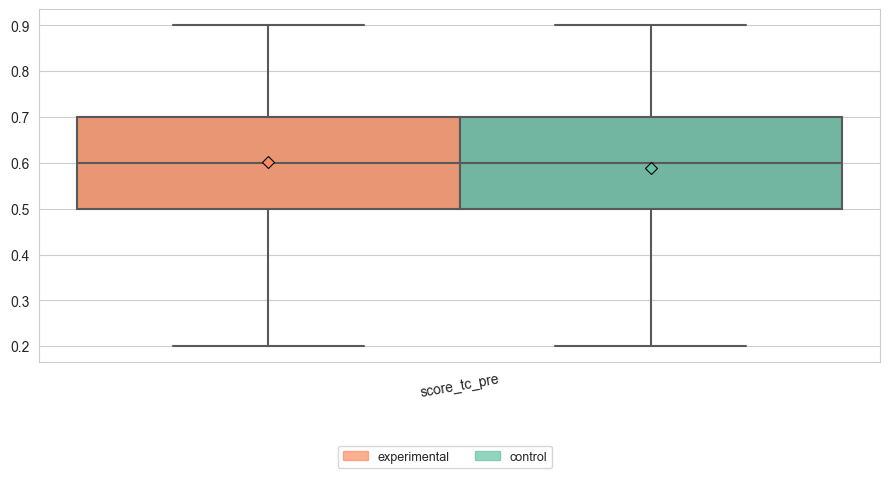

In [100]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(baseline_path, 'tc_pre.pdf')
)

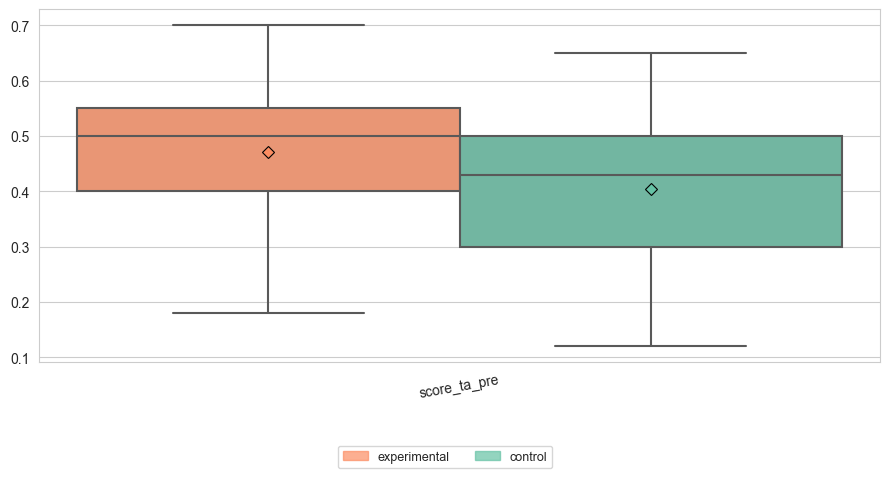

In [101]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_ta_pre"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(baseline_path, 'ta_pre.pdf')
)

## Experiment Results

### Experimental group

In [102]:
# plot_cat_distribution(
#     df = forms_interactions_df, 
#     cat_cols = [
#         "group"
#     ], 
#     max_cols=2, 
#     palette="Set2",
#     show_counts=True
# )

In [103]:
# plot_cat_distribution(
#     df = forms_interactions_df.filter(pl.col('group') == 'experimental'), 
#     cat_cols = [
#         'experimental_type_freq_quality',
#         'experimental_type_quality',
#         'experimental_type_v6',
#         'chat_freq_use'
#     ], 
#     max_cols=2, 
#     palette="Set2",
#     show_counts=True
# )

### Knowledge

In [104]:
knowledge_path = os.path.join(plots_path, '5_2', '5_2_2')

os.makedirs(knowledge_path, exist_ok=True)

#### Pre-Post Comparison

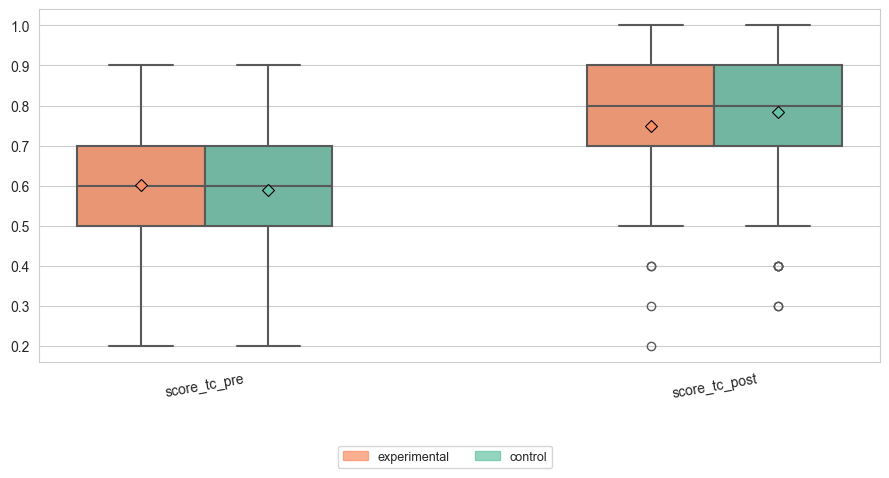

In [105]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_comparison.pdf')
)

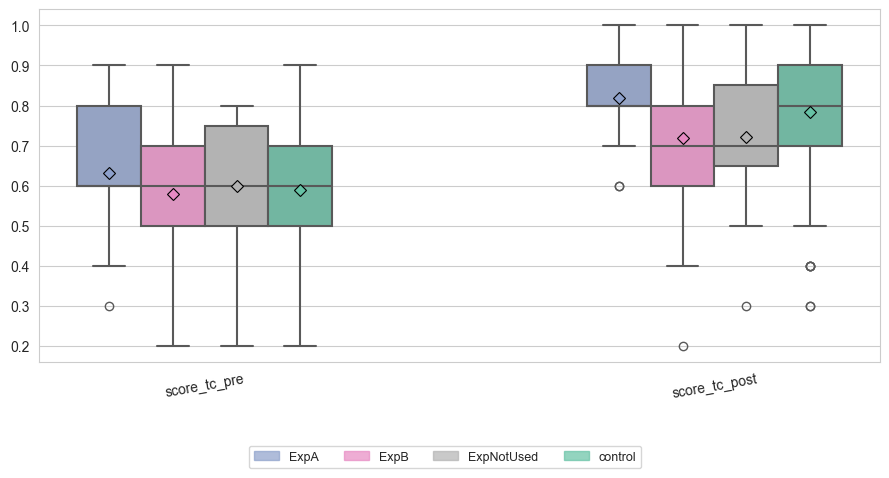

In [106]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_quality.pdf')
)

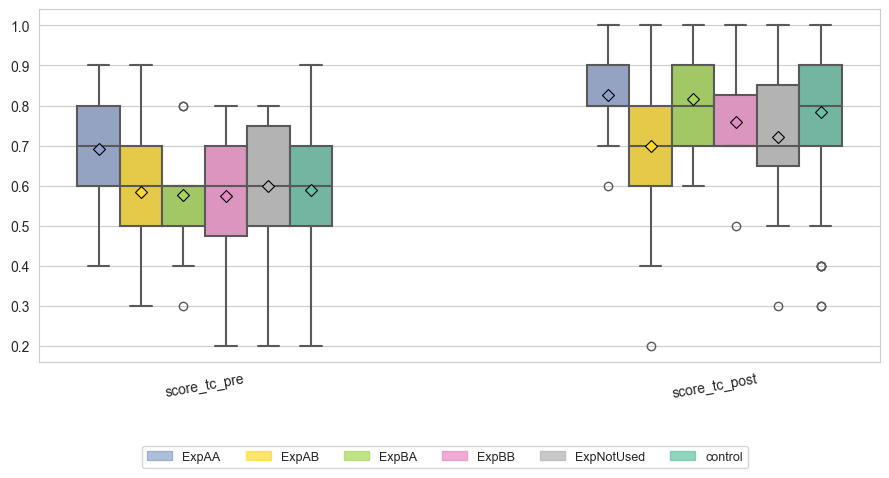

In [107]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by='group_segmented_freq_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(knowledge_path, 'pre_post_freq_quality.pdf')
)

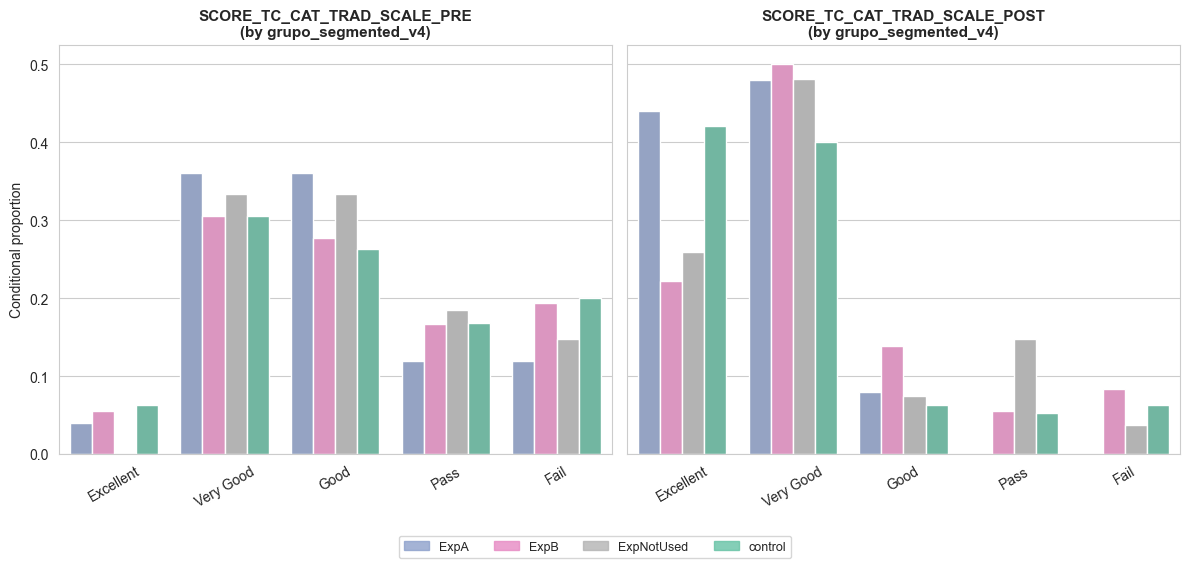

In [108]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['score_tc_cat_trad_scale_pre'], ['score_tc_cat_trad_scale_post'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.14),
    group_by='group_segmented_quality',
    sharey=True,
    order=['Excellent', 'Very Good', 'Good', 'Pass', 'Fail'],
    subplots_title=True,
    save_path=os.path.join(knowledge_path, 'pre_post_trad_scale.pdf')
)

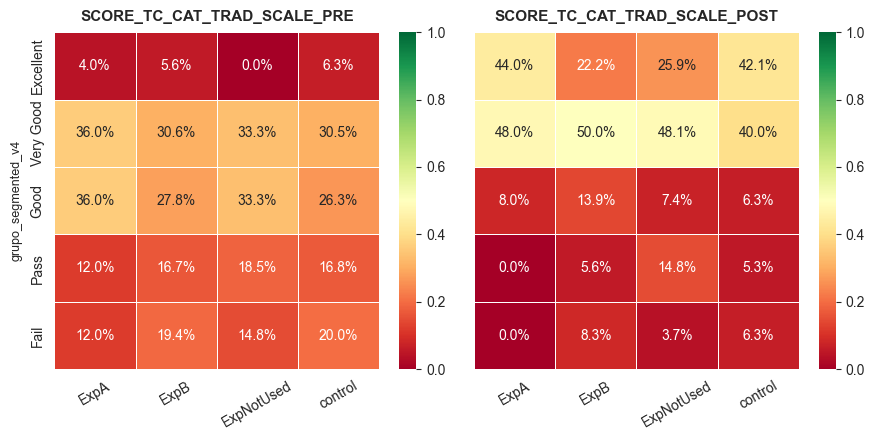

In [109]:
plot_cat_comparison_heatmap(
    df=forms_interactions_df,
    comparisons=[
        ['score_tc_cat_trad_scale_pre'], ['score_tc_cat_trad_scale_post'],
    ],
    group_by='group_segmented_quality',
    order=['Excellent', 'Very Good', 'Good', 'Pass', 'Fail'],
    title=None
)

EXPERIMENTAL:


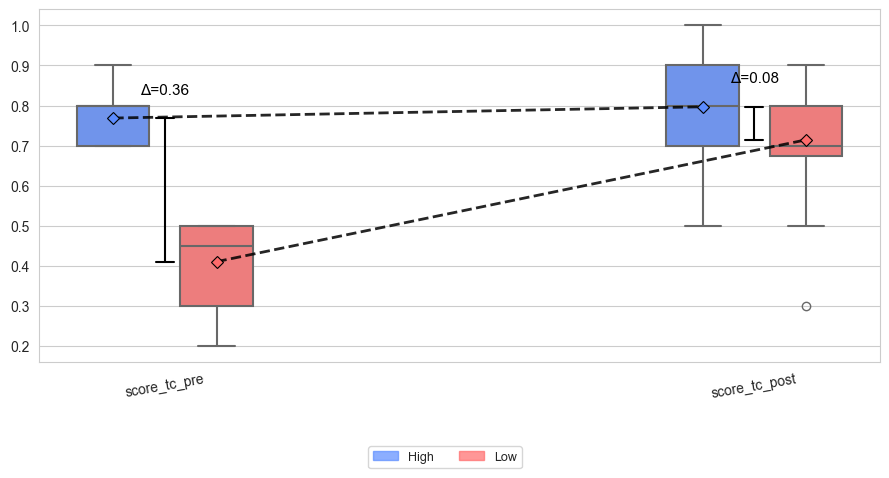

CONTROL:


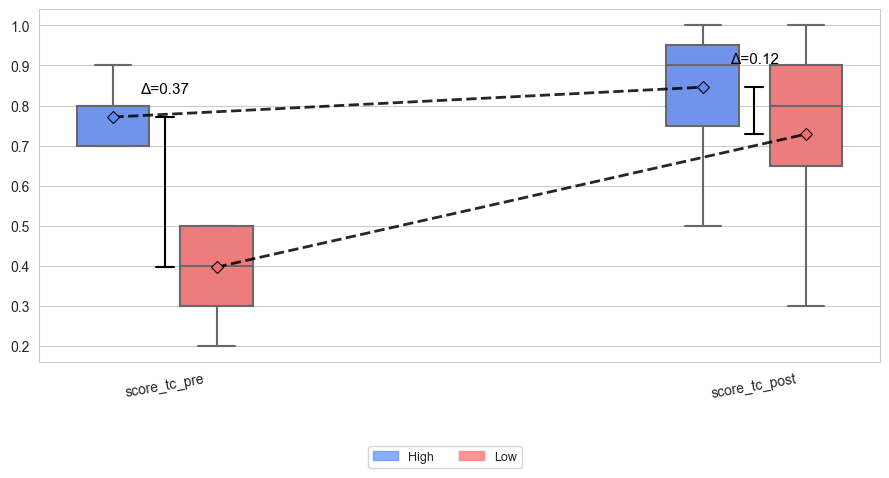

In [110]:
# Categorización adicional según el group al que pertenecen (solo para score_tc)
col = 'score_tc_pre'
df_cat_group = (
    forms_interactions_df.with_columns(
        pl.when(pl.col(col) <= 0.5).then(pl.lit("Low"))
        .when(pl.col(col) >= 0.7).then(pl.lit("High"))
        .alias(f"{col}_cat_new_group")
    )
)

df_cat_group_exp = df_cat_group.filter(
    pl.col("group") == "experimental"
)
df_cat_group_control = df_cat_group.filter(
    pl.col("group") == "control"
)

print("EXPERIMENTAL:")
plot_quant_comparison(
    figsize=(9, 4),
    df=df_cat_group_exp,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by=f"{col}_cat_new_group",
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    show_mean_lines=True,
    save_path=os.path.join(knowledge_path, 'mathew_experimental.pdf')
)

print("CONTROL:")
plot_quant_comparison(
    figsize=(9, 4),
    df=df_cat_group_control,
    comparisons=[
        ["score_tc_pre", "score_tc_post"]
    ],
    group_by=f"{col}_cat_new_group",
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    show_mean_lines=True,
    save_path=os.path.join(knowledge_path, 'mathew_control.pdf')
)

#### Hake Gain

In [111]:
no_efecto_techo_df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)).filter(
    pl.col("score_tc_pre") < 0.8	
)

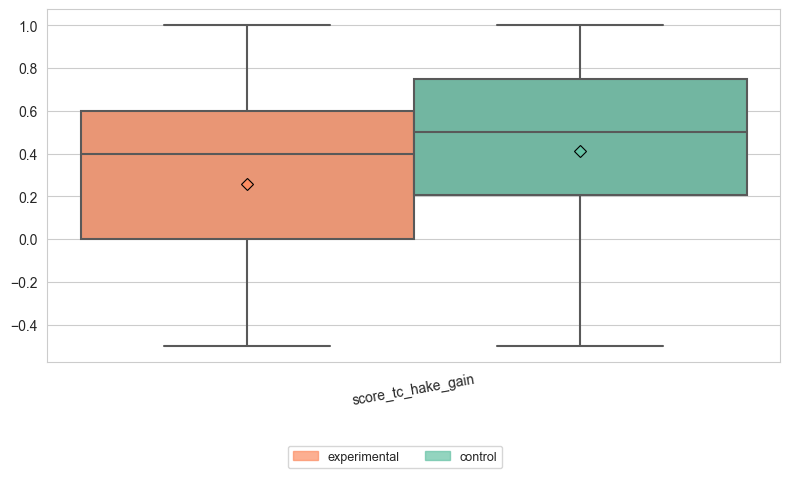

In [112]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
         ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    order=['experimental', 'control'],
    figsize=(8,4),
    save_path=os.path.join(knowledge_path, 'hake_gain_comparison.pdf')
)

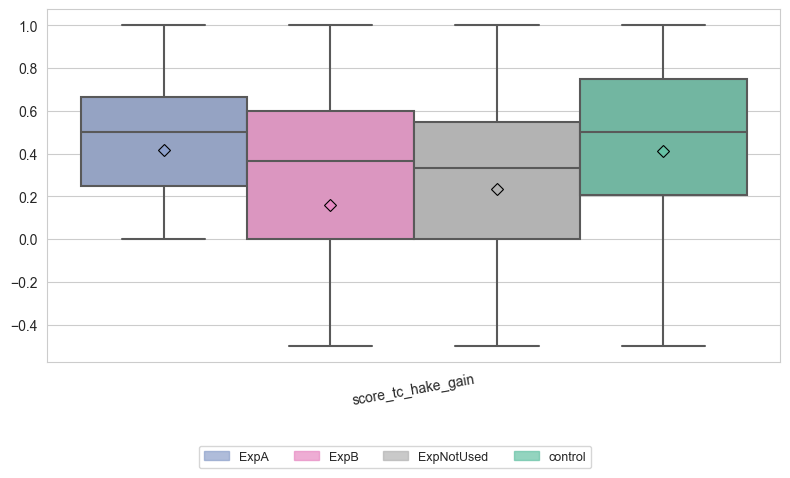

In [113]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    figsize=(8,4),
    save_path=os.path.join(knowledge_path, 'hake_gain_quality.pdf')
)

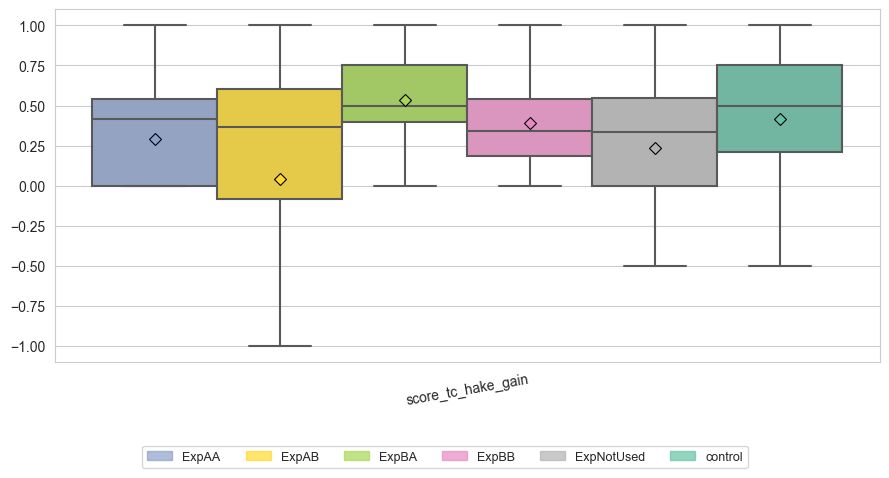

In [114]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_freq_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    save_path=os.path.join(knowledge_path, 'hake_gain_frq_quality.pdf')
)

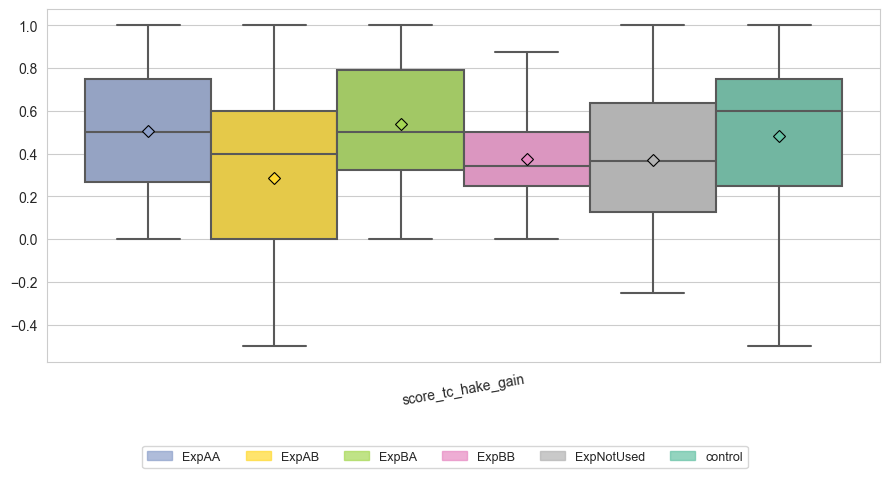

In [115]:
plot_quant_comparison(
    figsize = (9,4),
    df = no_efecto_techo_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        ["score_tc_hake_gain"] #hake_gain_quant_cols
    ],
    group_by='group_segmented_freq_quality',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title=None,
    save_path=os.path.join(knowledge_path, 'hake_gain_frq_quality_no_ceiling_effect.pdf')
)

#### Correlation plots

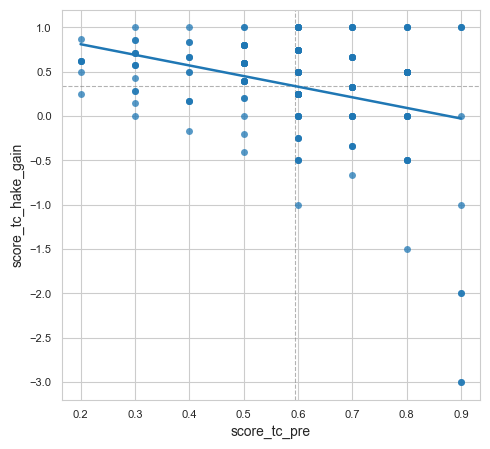

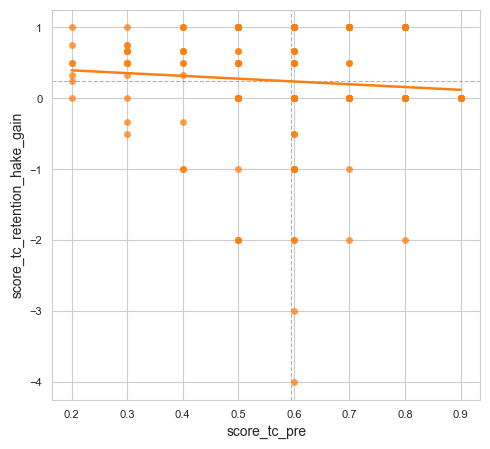

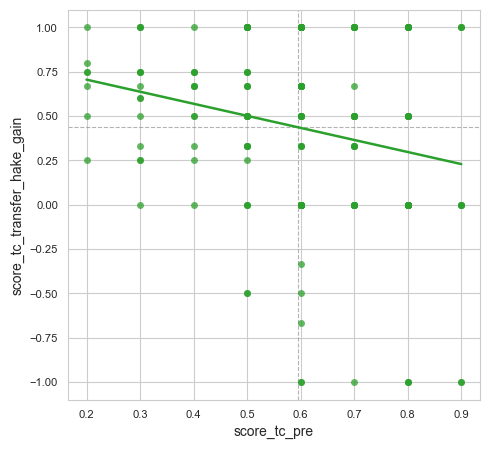

In [116]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_pre_hake_transfer.pdf')
)

In [117]:
cols_2 = [
    "score_tc_hake_gain",
    "score_tc_retention_hake_gain",
    "score_tc_transfer_hake_gain"
]

for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_tc_pre",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(-0.3303549661488646), 'pearson_p': np.float64(4.942284329654823e-06)}, 'spearman': {'spearman_r': np.float64(-0.23970104513400112), 'spearman_p': np.float64(0.001082433961517392)}}
{'pearson': {'pearson_r': np.float64(-0.08282993232857472), 'pearson_p': np.float64(0.264961257616635)}, 'spearman': {'spearman_r': np.float64(-0.12400637083543542), 'spearman_p': np.float64(0.0944269202777078)}}
{'pearson': {'pearson_r': np.float64(-0.23201183877031328), 'pearson_p': np.float64(0.0015759105238626163)}, 'spearman': {'spearman_r': np.float64(-0.1975772426590395), 'spearman_p': np.float64(0.00734153810617867)}}


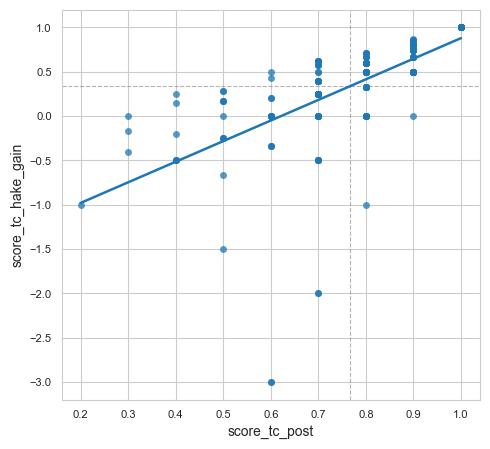

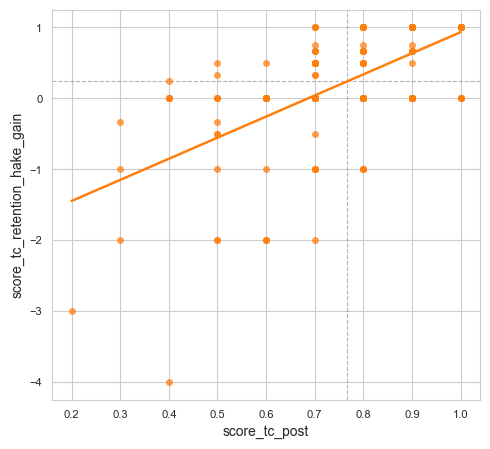

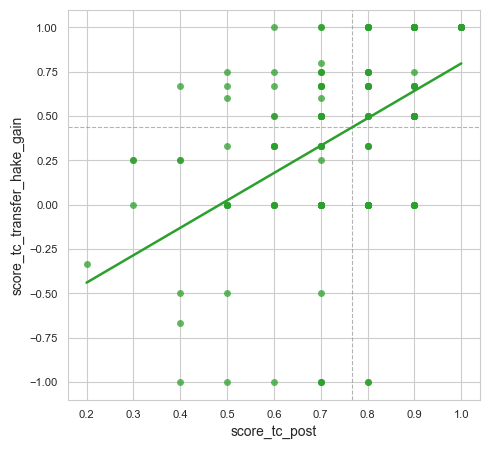

In [118]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_hake_gain"), 
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_post", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    title=None,
    subplots_title=False,
    corr_annotation=False,
    save_path=os.path.join(knowledge_path, 'correlation_post_hake_transfer.pdf')
)

In [119]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_tc_post",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.6320305667479138), 'pearson_p': np.float64(8.4360202573197855e-22)}, 'spearman': {'spearman_r': np.float64(0.8383864054743115), 'spearman_p': np.float64(1.4022925270836523e-49)}}
{'pearson': {'pearson_r': np.float64(0.618584411328048), 'pearson_p': np.float64(1.048724120601181e-20)}, 'spearman': {'spearman_r': np.float64(0.6310623205350168), 'spearman_p': np.float64(1.0156539885392935e-21)}}
{'pearson': {'pearson_r': np.float64(0.5196172293287241), 'pearson_p': np.float64(4.7998478465469655e-14)}, 'spearman': {'spearman_r': np.float64(0.5686424838981721), 'spearman_p': np.float64(4.576463317368351e-17)}}


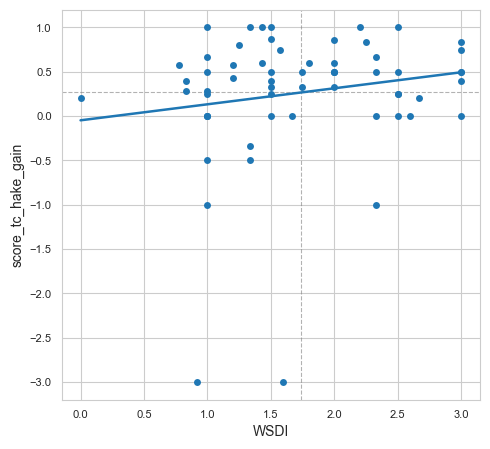

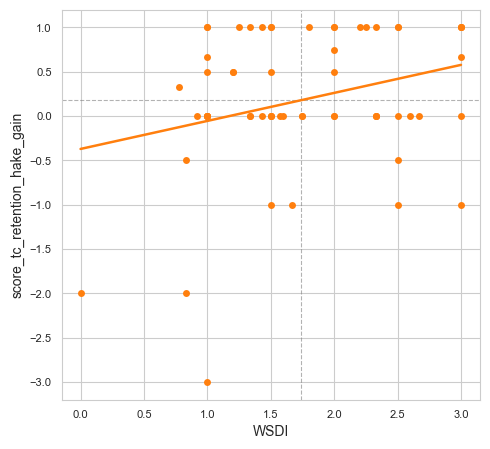

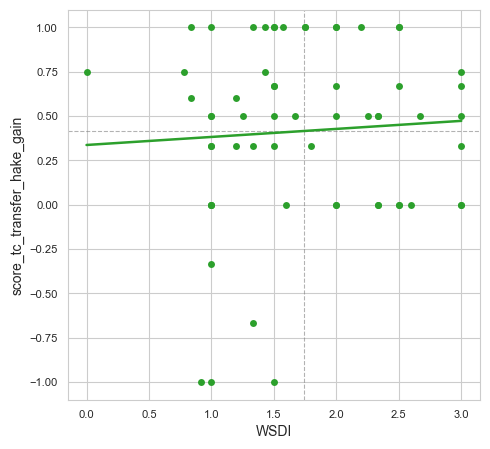

In [120]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("WSDI", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    corr_annotation=False,
    alpha=1,
    bbox_to_anchor=(0.5, -0.11), 
    title=None,
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_hake_transfer.pdf')
)

In [121]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "WSDI",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.17076180264597193), 'pearson_p': np.float64(0.18824483776505563)}, 'spearman': {'spearman_r': np.float64(0.1419290349279892), 'spearman_p': np.float64(0.27522736142406073)}}
{'pearson': {'pearson_r': np.float64(0.2726747702999409), 'pearson_p': np.float64(0.03349756279237057)}, 'spearman': {'spearman_r': np.float64(0.1829850520048646), 'spearman_p': np.float64(0.15808473703519776)}}
{'pearson': {'pearson_r': np.float64(0.06264872297530258), 'pearson_p': np.float64(0.6314754382267717)}, 'spearman': {'spearman_r': np.float64(0.014600276912902325), 'spearman_p': np.float64(0.9110782123527469)}}


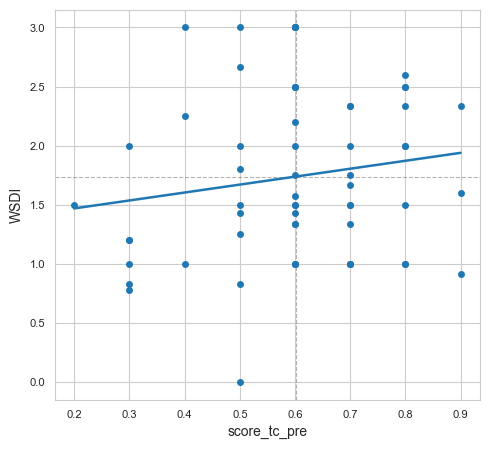

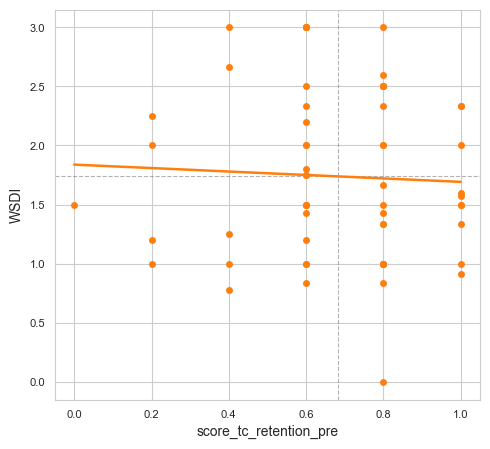

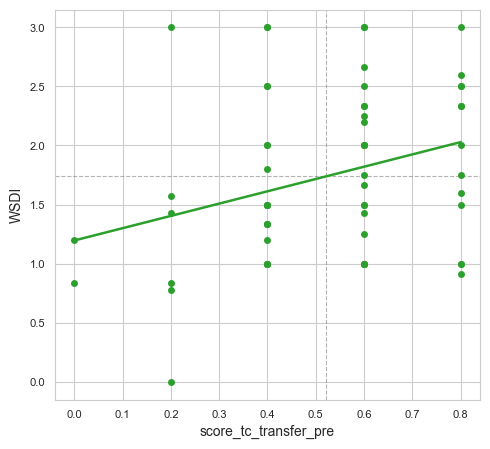

In [122]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_retention_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_tc_transfer_pre", "WSDI")
    ],
    corr_annotation=False,
    palette='tab10',
    alpha=1,
    bbox_to_anchor=(0.5, -0.11),
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'correlation_wsdi_pre_transfer.pdf')
)

In [123]:
cols_1 = [
    "score_tc_pre",
    "score_tc_retention_pre",
    "score_tc_transfer_pre"
]

for col in cols_1:
    results = compute_correlations(
        forms_interactions_df,
        col1 = col,
        col2 = "WSDI",
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.15747280276523376), 'pearson_p': np.float64(0.22549817544982417)}, 'spearman': {'spearman_r': np.float64(0.15141953889330345), 'spearman_p': np.float64(0.24406359935805919)}}
{'pearson': {'pearson_r': np.float64(-0.04783642776665884), 'pearson_p': np.float64(0.7142942830378224)}, 'spearman': {'spearman_r': np.float64(-0.05871664901124009), 'spearman_p': np.float64(0.6530763636824426)}}
{'pearson': {'pearson_r': np.float64(0.3052422189726033), 'pearson_p': np.float64(0.01675263385211422)}, 'spearman': {'spearman_r': np.float64(0.2979415219451923), 'spearman_p': np.float64(0.019695765813216897)}}


In [124]:
# plot_cat_comparison_faceted(
#     forms_interactions_df,
#     comparisons=[
#         ["WSDI_cat_v2"],
#     ],
#     outer_group_by= "WSDI_cat_v2",
#     outer_order=['Deep', 'Superficial', 'Cheating', 'Out of context', 'Not Used'],
#     order=["Low", "Medium", "High"],
#     group_by="score_tc_cat_pre",   #          
#     palette="Set2",
#     bbox_to_anchor=(0.5, 1),
#     sharey="all",
#     #save_path=os.path.join(knowledge_path, 'mejora_nota_pre.pdf')
# )

#### Mejora

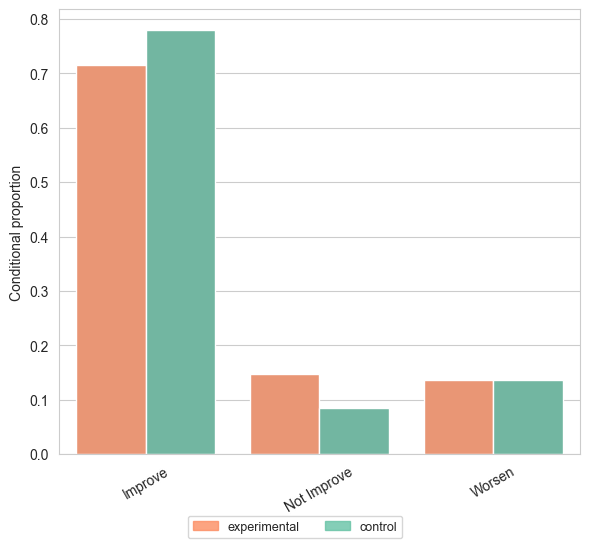

In [125]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain_v2'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group',
    order=['Improve', 'Not Improve', 'Worsen'],
    hue_order=['experimental', 'control'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'mejora_comparison.pdf')
)

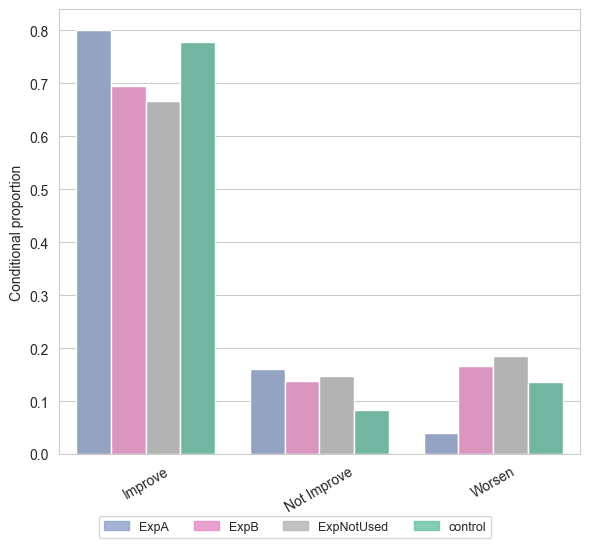

In [126]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain_v2'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'mejora_quality.pdf')
)


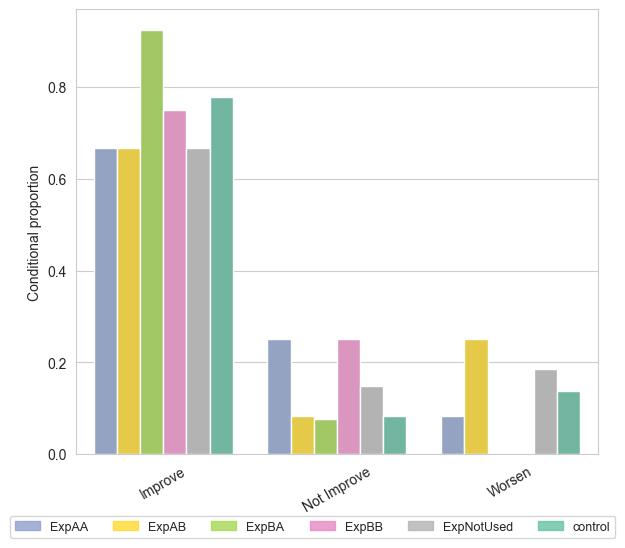

In [127]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['improvement_hake_gain_v2'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_freq_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'mejora_frq_quality.pdf')
)

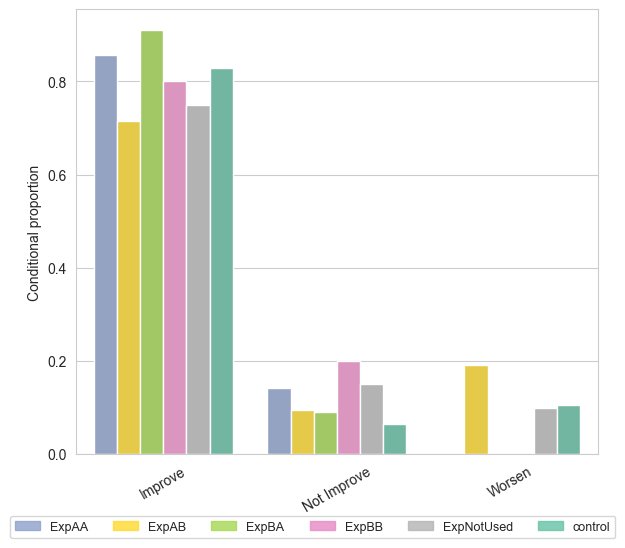

In [128]:
plot_cat_comparison(
    df=no_efecto_techo_df, 
    comparisons=[
        ['improvement_hake_gain_v2'],
    ], 
    title=None,
    bbox_to_anchor=(0.5,-0.1),
    group_by='group_segmented_freq_quality',
    order=['Improve', 'Not Improve', 'Worsen'],
    subplots_title=False,
    save_path=os.path.join(knowledge_path, 'mejora_frq_quality_ceiling_effect.pdf')
)


In [129]:
# plot_cat_comparison_faceted(
#     forms_interactions_df,
#     comparisons=[
#         ["improvement_hake_gain_v2"],
#     ],
#     outer_group_by= "score_tc_cat_pre",
#     outer_order=["Low", "Medium", "High"],
#     order=['Improve', 'Not Improve', 'Worsen'],
#     group_by="group_segmented_quality",            
#     palette="Set2",
#     bbox_to_anchor=(0.5, 1),
#     sharey="all",
#     save_path=os.path.join(knowledge_path, 'mejora_nota_pre.pdf')
# )

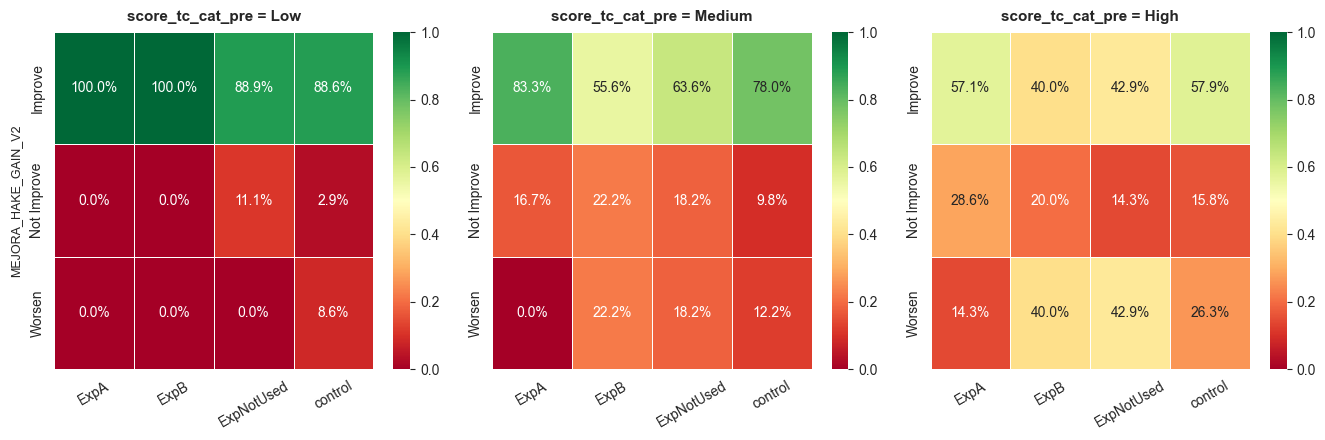

In [130]:
plot_cat_comparison_faceted_heatmap(
    forms_interactions_df,
    comparisons=[
        ["improvement_hake_gain_v2"],
    ],
    outer_group_by="score_tc_cat_pre",
    outer_order=["Low", "Medium", "High"],
    order=['Improve', 'Not Improve', 'Worsen'],
    group_by="group_segmented_quality",
    cmap="RdYlGn",
    show_counts=True,
    save_path=os.path.join(knowledge_path, 'mejora_nota_pre_heatmap.pdf'),
)

#### Evaluation Chat

In [131]:
# plot_cat_comparison(
#     df=forms_interactions_df.filter(
#         pl.col('group') == 'experimental',
#         pl.col('evaluation_pass').is_not_null()
#     ), 
#     comparisons=[
#         ['evaluation_pass'],
#     ], 
#     title=None,
#     hue_order=["Not Used", "Out of context", "Cheating", "Superficial", "Deep"], 
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='WSDI_cat_v2',
#     subplots_title=False,
#     save_path=os.path.join(knowledge_path, 'evaluation_pass_by_depth.pdf')
# )

In [132]:
# cheating_not_cheating = forms_interactions_df.with_columns(
#     pl.when(pl.col("WSDI_cat_v2") == "Cheating")
#     .then(pl.lit("Cheating"))
#     .otherwise(pl.lit("No Cheating"))
#     .alias("do_cheat")
# ).filter(
#     pl.col("evaluation_pass").is_not_null()
# ).with_columns(
#     pl.col("evaluation_pass").cast(pl.String),
# )

# plot_cat_comparison_faceted(
#     cheating_not_cheating,
#     comparisons=[
#         ["improvement_hake_gain_v2"],
#     ],
#     outer_group_by="do_cheat",
#     group_by="evaluation_pass",        
#     palette="Set2",
#     bbox_to_anchor=(0.5, 1),
#     sharey="all",
#     order=['Improve', 'Not Improve', 'Worsen'],
#     save_path=os.path.join(knowledge_path, 'evaluation_pass_mejora.pdf')
# )

### Self-efficiency

In [133]:
self_efficacy_path = os.path.join(plots_path, '5_2', '5_2_3')
os.makedirs(self_efficacy_path, exist_ok=True)

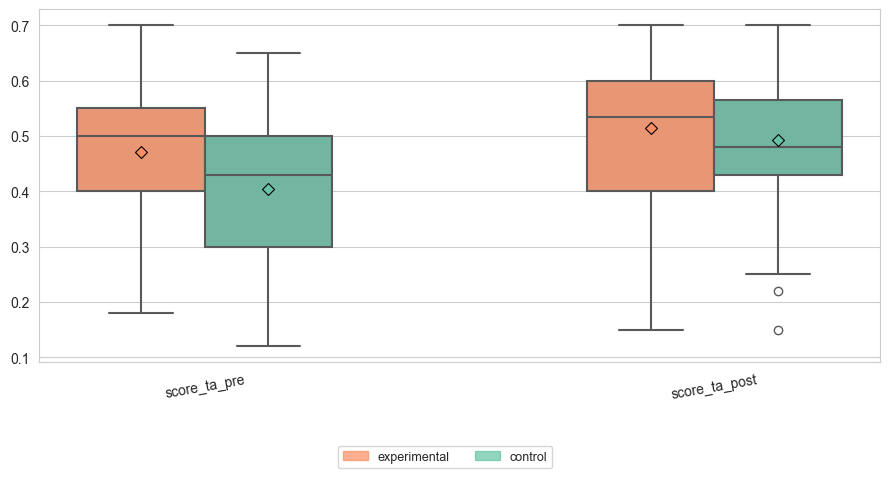

In [134]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_ta_pre', 'score_ta_post']
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(self_efficacy_path, 'self_confidence_comparison.pdf')
)

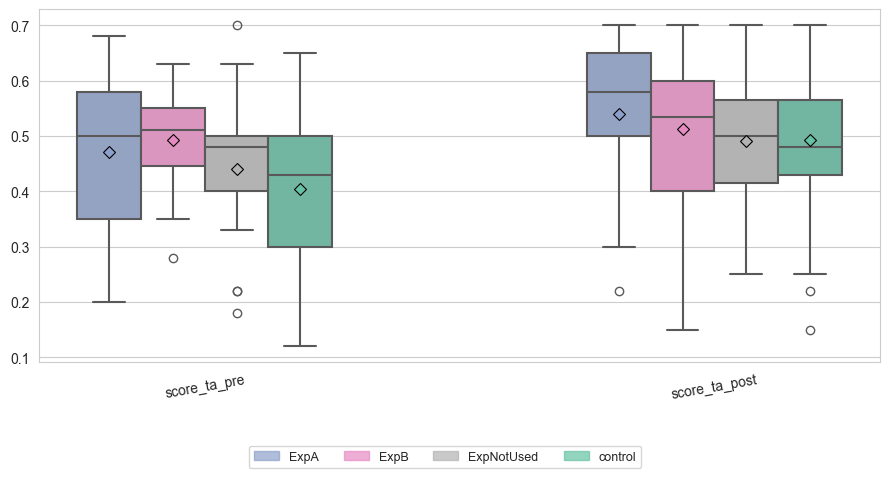

In [135]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_ta_pre', 'score_ta_post']
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(self_efficacy_path, 'self_confidence_quality.pdf')
)

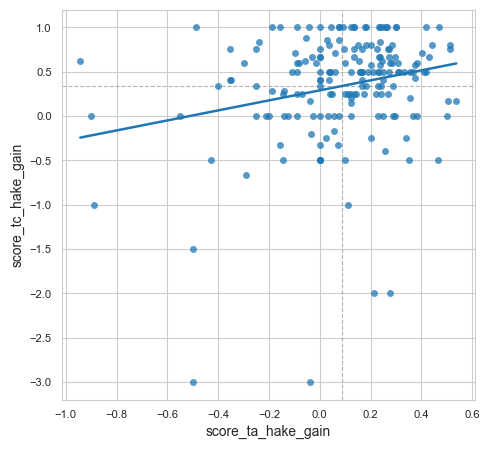

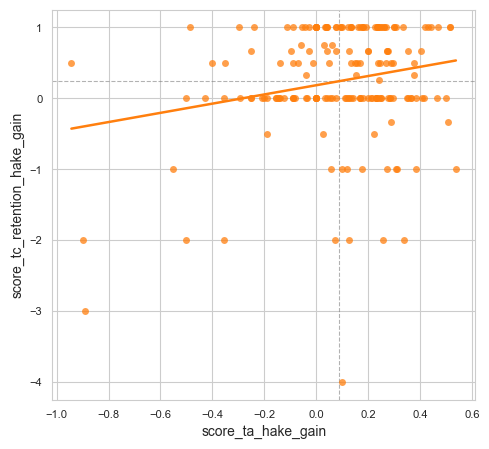

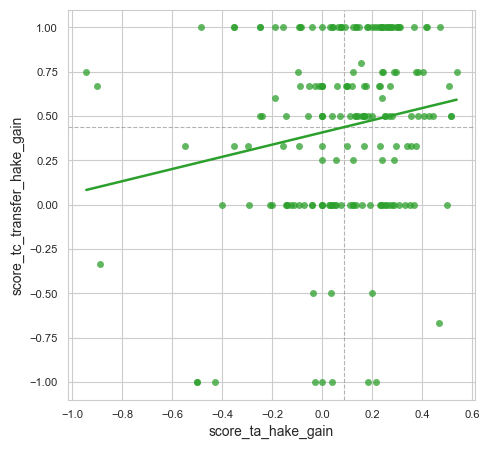

In [136]:
plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_general.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_retention_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_retention.pdf')
)

plot_quant_scatter(
    forms_interactions_df,
    comparisons=[
        ("score_ta_hake_gain", "score_tc_transfer_hake_gain")
    ],
    palette="tab10",
    alpha=0.75,
    bbox_to_anchor=(0.5, -0.12),
    corr_annotation=False,
    subplots_title=False,
    save_path=os.path.join(self_efficacy_path, 'self_confidence_hake_gain_transfer.pdf')
)

In [137]:
for col in cols_2:
    results = compute_correlations(
        forms_interactions_df,
        col1 = "score_ta_hake_gain",
        col2 = col,
    )

    print(results)

{'pearson': {'pearson_r': np.float64(0.2284550564311273), 'pearson_p': np.float64(0.001867411376682705)}, 'spearman': {'spearman_r': np.float64(0.1673013771194766), 'spearman_p': np.float64(0.023593694929186913)}}
{'pearson': {'pearson_r': np.float64(0.20074337649088067), 'pearson_p': np.float64(0.0064342070098755075)}, 'spearman': {'spearman_r': np.float64(0.07214503644880091), 'spearman_p': np.float64(0.3317784424920426)}}
{'pearson': {'pearson_r': np.float64(0.1719057150325125), 'pearson_p': np.float64(0.019969938156901994)}, 'spearman': {'spearman_r': np.float64(0.1517188279701536), 'spearman_p': np.float64(0.040341522910350654)}}


### Cognitive load

In [138]:
cognitive_load_path = os.path.join(plots_path, '5_2', '5_2_4')

In [139]:
# plot_cat_comparison(
#     df=forms_interactions_df, 
#     comparisons=[
#         ['score_tcc_rel_cat_post'], ['score_tcc_ext_cat_post'], ['score_tcc_int_cat_post'],
#     ], 
#     title=None,
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='group',
#     order=["Low", "Medium", "High"],
#     hue_order=['experimental', 'control'],
#     save_path=os.path.join(cognitive_load_path, 'tcc_levels.pdf')
# )

In [140]:
# plot_cat_comparison(
#     df=forms_interactions_df, 
#     comparisons=[
#         ['score_tcc_rel_cat_post'], ['score_tcc_ext_cat_post'], ['score_tcc_int_cat_post'],
#     ], 
#     title=None,
#     bbox_to_anchor=(0.5,-0.1),
#     group_by='group_segmented_quality',
#     order=["Low", "Medium", "High"],
#     save_path=os.path.join(cognitive_load_path, 'tcc_levels_quality.pdf')
# )

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\migue.MSI\\Desktop\\IBiDat\\Papers\\va-educational-impact\\src\\notebooks\\paper\\..\\..\\..\\plots\\5_2\\5_2_4\\tcc_comparison.pdf'

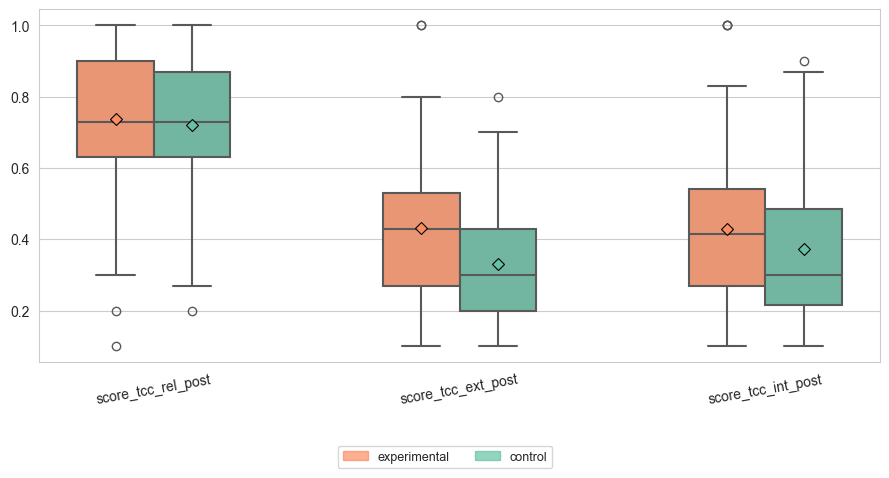

In [141]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='group',
    showfliers=True,
    title=None,
    order=['experimental', 'control'],
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_comparison.pdf')
)

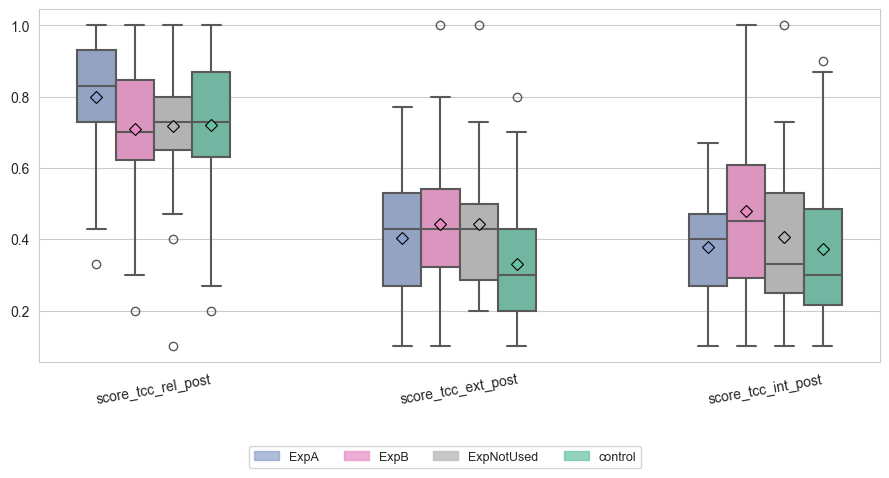

In [ ]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='group_segmented_quality',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_comparison_quality.pdf')
)

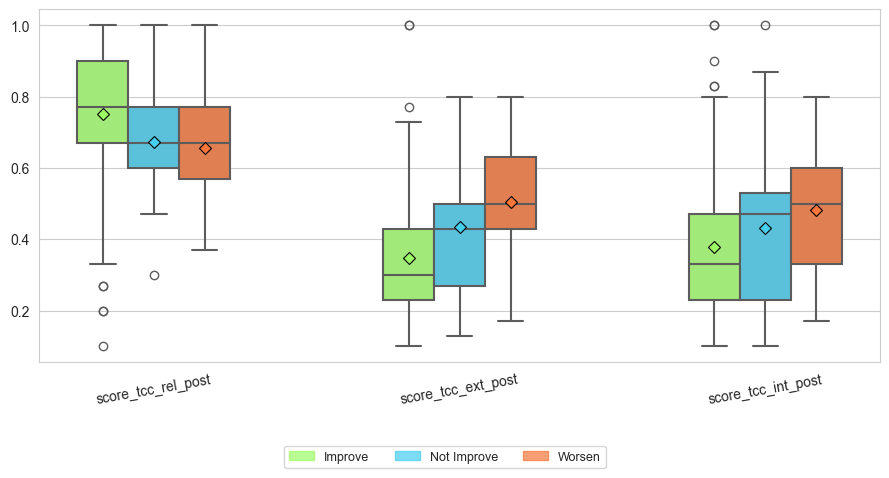

In [ ]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ['score_tcc_rel_post', 'score_tcc_ext_post', 'score_tcc_int_post']
    ],
    group_by='improvement_hake_gain_v2',
    showfliers=True,
    title=None,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    save_path=os.path.join(cognitive_load_path, 'tcc_mejora.pdf')
)

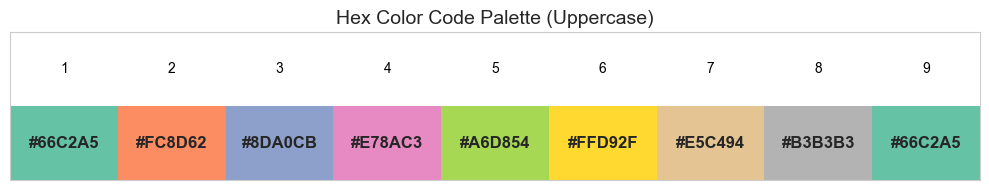

Uppercase hex palette:
['#66C2A5', '#FC8D62', '#8DA0CB', '#E78AC3', '#A6D854', '#FFD92F', '#E5C494', '#B3B3B3', '#66C2A5']


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Get a color palette (any desired palette)
palette = sns.color_palette("Set2", 9)  # You can change this to any palette name

# Convert hex codes to uppercase
uppercase_palette = [mcolors.rgb2hex(color).upper() for color in palette]

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Display colors
for i, color in enumerate(uppercase_palette):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='none'))
    ax.text(i + 0.5, 0.5, color, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(i + 0.5, 1.5, str(i + 1), ha='center', va='center', fontsize=10, color='black')

ax.set_xlim(0, len(uppercase_palette))
ax.set_ylim(0, 2)
ax.set_title('Hex Color Code Palette (Uppercase)', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Print the palette for reference
print("Uppercase hex palette:")
print(uppercase_palette)